# Deep Multimodal Fraud Detection

Combines image features (CNN backbone) with transaction features (MLP)
via late fusion on the mixed-all multimodal dataset.

### Research question
Does combining both modalities improve fraud detection compared to
image-only or tabular-only baselines?

### Architecture
```
Image  → CNN backbone → flatten → projector ──────────┐
                                                        ├→ concat → fusion head → logit
Tab features → MLP encoder ───────────────────────────┘
```

### Four experiments — two axes of comparison

| Exp | Tabular features | Training | Purpose |
|---|---|---|---|
| A | Raw (7 features) | Normal | Basic multimodal baseline |
| B | Raw (7 features) | WeightedSampler | Debiased — combo/source balancing |
| C | Engineered (12 features) | Normal | Does FE improve multimodal learning? |
| D | Engineered (12 features) | WeightedSampler | Final strongest model |

**Axis 1 — Feature engineering** (A vs C, B vs D): same as notebook 12/18
**Axis 2 — Imbalance handling** (A vs B, C vs D): WeightedRandomSampler
instead of SMOTE (cannot create synthetic image-transaction pairs)

### Key imbalance note
No SMOTE for multimodal models. Instead, WeightedRandomSampler balances
by combo_type × img_source_dataset to reduce MIDV dominance in batches.

### IMPORTANT: Features used
Tab branch uses ONLY transaction features. These are EXCLUDED:
- `tab_isFraud` ← leaks the label (final_label is derived from it)
- `img_final_label`, `img_image_class`, `combo_type` ← encode the label

## 0 · Imports & reproducibility

In [1]:
import sys, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import (roc_curve, auc as sk_auc,
                             precision_recall_curve, average_precision_score)

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from multimodal_utils import (
    MultimodalFraudDetector,
    engineer_features, validate_features,
    TAB_RAW, TAB_ALL_FE, TARGET_COL,
    fit_scaler, build_dataloaders, build_weighted_sampler,
    make_loss_fn, fit_model, predict_probs,
    compute_metrics, tune_threshold,
    run_test_evaluation, subgroup_by_combo,
)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")

Device : cpu  |  PyTorch 2.11.0+cpu


## 1 · Config

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

# ── Choose backbone ────────────────────────────────────────────────────────
BACKBONE = "resnet18"    # or "efficientnet_b0"
# ──────────────────────────────────────────────────────────────────────────

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE  = 32
NUM_WORKERS = 0
STAGE1_EPOCHS   = 5;  STAGE1_LR = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20; BACKBONE_LR = 1e-5; HEAD_LR = 1e-4; STAGE2_PATIENCE = 6

RESULTS_BASE = PROJECT_ROOT / "notebook" / "results" / f"mm_deep_{BACKBONE}"
EXP_DIRS = {
    "A_raw_normal":    RESULTS_BASE / "A_raw_normal",
    "B_raw_sampler":   RESULTS_BASE / "B_raw_sampler",
    "C_fe_normal":     RESULTS_BASE / "C_fe_normal",
    "D_fe_sampler":    RESULTS_BASE / "D_fe_sampler",
}
for d in EXP_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print(f"Backbone    : {BACKBONE}")
print(f"Results base: {RESULTS_BASE}")

Backbone    : resnet18
Results base: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18


## 2 · Load data & feature engineering

In [3]:
train_raw = pd.read_csv(TRAIN_CSV)
val_raw   = pd.read_csv(VAL_CSV)
test_raw  = pd.read_csv(TEST_CSV)

# Feature engineered versions
train_fe = engineer_features(train_raw)
val_fe   = engineer_features(val_raw)
test_fe  = engineer_features(test_raw)

print(f"Train: {len(train_raw):,} | Val: {len(val_raw):,} | Test: {len(test_raw):,}")
print(f"\nRaw features ({len(TAB_RAW)}):        {TAB_RAW}")
print(f"Engineered features ({len(TAB_ALL_FE)}): {TAB_ALL_FE}")

# Verify no forbidden columns
validate_features(TAB_RAW)
validate_features(TAB_ALL_FE)
print("\nFeature validation passed — no label leakage.")

# Scalers — fitted on training data ONLY
scaler_raw = fit_scaler(train_raw, TAB_RAW)
scaler_fe  = fit_scaler(train_fe,  TAB_ALL_FE)

Train: 7,182 | Val: 1,508 | Test: 1,474

Raw features (7):        ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud']
Engineered features (12): ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed']
Feature validation passed — 7 features, no leakage.
Feature validation passed — 12 features, no leakage.

Feature validation passed — no label leakage.
Feature validation passed — 7 features, no leakage.
Scaler fitted on 7 features: ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud']
Feature validation passed — 12 features, no leakage.
Scaler fitted on 12 features: ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_ne

## 3 · Dataset imbalance analysis

Two types of imbalance exist in the multimodal dataset.
This motivates the WeightedRandomSampler in experiments B and D.

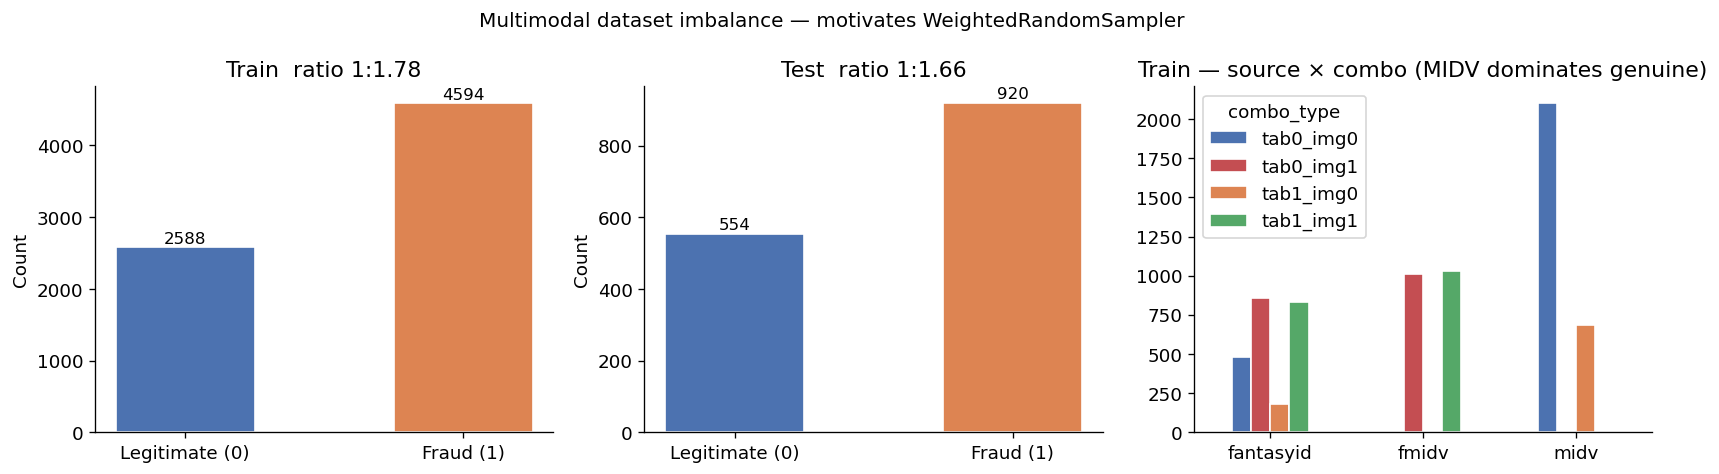

Auto pos_weight = 2588/4594 = 0.563  (DOWN-weights fraud, the majority class)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Label distribution
for ax, (name, df) in zip(axes[:2], [("Train",train_raw),("Test",test_raw)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}"); ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)

# Source x combo imbalance
COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}
if "img_source_dataset" in train_raw.columns:
    pd.crosstab(train_raw["img_source_dataset"],
                train_raw["combo_type"]).plot(
        kind="bar", ax=axes[2],
        color=list(COMBO_COLOURS.values()), edgecolor="white")
    axes[2].set_title("Train — source × combo (MIDV dominates genuine)")
    axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=0)
    axes[2].spines[["top","right"]].set_visible(False)

fig.suptitle("Multimodal dataset imbalance — motivates WeightedRandomSampler",
             fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "imbalance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

n0 = (train_raw[TARGET_COL]==0).sum()
n1 = (train_raw[TARGET_COL]==1).sum()
print(f"Auto pos_weight = {n0}/{n1} = {n0/n1:.3f}  (DOWN-weights fraud, the majority class)")

## 4 · Training helper

In [5]:
def run_experiment(exp_id, train_df, val_df, test_df,
                   scaler, tab_cols, use_sampler, pos_weight_override=None):
    """
    Full two-stage train + evaluation for one experiment.

    Parameters
    ----------
    exp_id              : label string e.g. "A_raw_normal"
    tab_cols            : TAB_RAW or TAB_ALL_FE
    use_sampler         : True = WeightedRandomSampler by combo×source
    pos_weight_override : None = auto-computed, float = override
    """
    results_dir = EXP_DIRS[exp_id]
    print(f"\n{'='*60}")
    print(f"EXPERIMENT {exp_id}")
    print(f"  tab features  : {len(tab_cols)} ({tab_cols[:3]}...)")
    print(f"  use_sampler   : {use_sampler}")
    print(f"  pos_weight    : {'auto' if pos_weight_override is None else pos_weight_override}")
    print(f"{'='*60}")

    loss_fn = make_loss_fn(train_df, device, pos_weight_override)
    train_loader, val_loader, test_loader = build_dataloaders(
        train_df, val_df, test_df, scaler, tab_cols,
        batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
        use_sampler=use_sampler,
    )

    # Stage 1 — frozen backbone
    h_s1 = None
    if (results_dir / "stage1_best.pt").exists():
        print("Stage 1 already trained — skipping.")
        model = MultimodalFraudDetector(
            backbone=BACKBONE, tab_input_dim=len(tab_cols),
            pretrained=False).to(device)
        model.freeze_backbone()
        model.load_state_dict(
            torch.load(results_dir/"stage1_best.pt", map_location=device))
    else:
        model = MultimodalFraudDetector(
            backbone=BACKBONE, tab_input_dim=len(tab_cols),
            pretrained=True).to(device)
        model.freeze_backbone()
        opt1 = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=STAGE1_LR, weight_decay=1e-4)
        model, h_s1 = fit_model(
            model=model, train_loader=train_loader, val_loader=val_loader,
            loss_fn=loss_fn, optimizer=opt1, device=device,
            epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
            monitor_metric="val_roc_auc",
            model_save_path=results_dir/"stage1_best.pt")
        display(h_s1.round(4))

    # Stage 2 — full fine-tuning
    if (results_dir / "stage2_best.pt").exists():
        print("Stage 2 already trained — skipping.")
        model.unfreeze_backbone()
        model.load_state_dict(
            torch.load(results_dir/"stage2_best.pt", map_location=device))
    else:
        model.unfreeze_backbone()
        backbone_p = list(model.image_backbone.parameters())
        head_p     = (list(model.image_projector.parameters()) +
                      list(model.tab_encoder.parameters()) +
                      list(model.fusion_head.parameters()))
        opt2 = torch.optim.Adam(
            [{"params": backbone_p, "lr": BACKBONE_LR},
             {"params": head_p,     "lr": HEAD_LR}],
            weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
        model, h_s2 = fit_model(
            model=model, train_loader=train_loader, val_loader=val_loader,
            loss_fn=loss_fn, optimizer=opt2, device=device,
            epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
            monitor_metric="val_roc_auc", scheduler=sched,
            model_save_path=results_dir/"stage2_best.pt")
        hist = (pd.concat([h_s1, h_s2], ignore_index=True)
                if h_s1 is not None else h_s2.copy())
        hist["epoch_global"] = range(1, len(hist)+1)
        hist.to_csv(results_dir/"training_history.csv", index=False)
        display(h_s2.round(4))

    model.eval()

    # Threshold + evaluation
    val_y, val_p     = predict_probs(model, val_loader, device)
    best_t, sweep_df = tune_threshold(val_y, val_p, metric="f1")
    sweep_df.to_csv(results_dir/"threshold_sweep.csv", index=False)

    test_metrics = run_test_evaluation(
        model=model, test_loader=test_loader,
        loss_fn=loss_fn, device=device, threshold=best_t)

    y_true, y_prob = predict_probs(model, test_loader, device)
    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["y_true"] = y_true; pred_df["y_prob"] = y_prob
    pred_df["y_pred"] = (pred_df["y_prob"] >= best_t).astype(int)
    pred_df.to_csv(results_dir/"test_predictions.csv", index=False)

    sg = subgroup_by_combo(pred_df, best_t, exp_id)
    sg.to_csv(results_dir/"subgroup_combo_type.csv", index=False)

    def get_f1(combo):
        r = sg[sg["combo_type"]==combo]
        return r["f1"].values[0] if len(r)>0 else float("nan")

    print(f"  tab0_img0 F1: {get_f1('tab0_img0'):.3f}  (image-only was 0.000)")
    print(f"  tab1_img0 F1: {get_f1('tab1_img0'):.3f}  (image-only was ~0.35)")

    return {"id":exp_id, "label":exp_id, "threshold":best_t,
            "metrics":test_metrics, "pred_df":pred_df,
            "sg":sg, "y_true":y_true, "y_prob":y_prob}

---
## 5 · Experiment A — Raw features, normal training
Basic multimodal baseline.

In [6]:
res_A = run_experiment("A_raw_normal", train_raw, val_raw, test_raw,
                        scaler_raw, TAB_RAW,
                        use_sampler=False, pos_weight_override=None)


EXPERIMENT A_raw_normal
  tab features  : 7 (['tab_type', 'tab_amount', 'tab_oldbalanceOrg']...)
  use_sampler   : False
  pos_weight    : auto
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Stage 1 already trained — skipping.
MultimodalFraudDetector | backbone=resnet18 | tab_dim=7 | fusion_dim=256 | params=11,409,217
Backbone frozen.
Stage 2 already trained — skipping.
Backbone unfrozen — all parameters trainable.
Best threshold (f1): 0.25

── TEST METRICS ──────────────────────────────
  loss        : 0.1921
  accuracy    : 0.8982
  precision   : 0.8945
  recall      : 0.9489
  f1          : 0.9209
  roc_auc     : 0.9671
  confusion_matrix:
[[451 103]
 [ 47 873]]
──────────────────────────────────────────────

── A_raw_normal subgroup by combo_type ──
  tab0_img0 F1: 0.000  (image-only was 0.000)
  

---
## 6 · Experiment B — Raw features, WeightedSampler
Debiased baseline — balances combo×source in batches.

In [7]:
res_B = run_experiment("B_raw_sampler", train_raw, val_raw, test_raw,
                        scaler_raw, TAB_RAW,
                        use_sampler=True, pos_weight_override=None)


EXPERIMENT B_raw_sampler
  tab features  : 7 (['tab_type', 'tab_amount', 'tab_oldbalanceOrg']...)
  use_sampler   : True
  pos_weight    : auto
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
Stage 1 already trained — skipping.
MultimodalFraudDetector | backbone=resnet18 | tab_dim=7 | fusion_dim=256 | params=11,409,217
Backbone frozen.
Stage 2 already trained — skipping.
Backbone unfrozen — all paramet

---
## 7 · Experiment C — Engineered features, normal training
Same balance-delta features as XGBoost (notebook 18).

In [ ]:
from pathlib import Path

results_dir = Path(r"results\mm_deep_resnet18\C_fe_normal"
                   )

EXP_DIRS = {
    "C_fe_normal": results_dir
}

In [9]:
res_C = run_experiment("C_fe_normal", train_fe, val_fe, test_fe,
                        scaler_fe, TAB_ALL_FE,
                        use_sampler=False, pos_weight_override=None)


EXPERIMENT C_fe_normal
  tab features  : 12 (['tab_type', 'tab_amount', 'tab_oldbalanceOrg']...)
  use_sampler   : False
  pos_weight    : auto
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Stage 1 already trained — skipping.
MultimodalFraudDetector | backbone=resnet18 | tab_dim=12 | fusion_dim=256 | params=11,409,857
Backbone frozen.
Backbone unfrozen — all parameters trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.2116 | val_loss=0.2068 | val_f1=0.8617 | val_roc_auc=0.9588
  ✓ Saved best model (epoch 1, val_roc_auc=0.9588)
Epoch 02 | lr=9.94e-06 | train_loss=0.1953 | val_loss=0.2074 | val_f1=0.8636 | val_roc_auc=0.9600
  ✓ Saved best model (epoch 2, val_roc_auc=0.9600)
Epoch 03 | lr=9.76e-06 | train_loss=0.1897 | val_loss=0.1956 | val_f1=0.8680 | val_roc_auc=0.9666
  ✓ Saved best model (epoch 3

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.2116,0.2068,0.8382,0.9348,0.7992,0.8617,0.9588
1,2,0.0,0.1953,0.2074,0.8408,0.9394,0.7992,0.8636,0.9600
2,3,0.0,0.1897,0.1956,0.8475,0.9558,0.7950,0.8680,0.9666
3,4,0.0,0.1878,0.2019,0.8402,0.9482,0.7897,0.8617,0.9639
4,5,0.0,0.1844,0.2217,0.8123,0.9418,0.7487,0.8342,0.9540
5,6,0.0,0.1847,0.1789,0.8714,0.9296,0.8612,0.8941,0.9683
6,7,0.0,0.1824,0.1670,0.8733,0.9460,0.8475,0.8941,0.9727
7,8,0.0,0.1760,0.1725,0.8687,0.9363,0.8496,0.8908,0.9692
8,9,0.0,0.1693,0.1629,0.8621,0.9438,0.8307,0.8837,0.9714
9,10,0.0,0.1732,0.1668,0.8614,0.9502,0.8233,0.8823,0.9720


Best threshold (f1): 0.35

── TEST METRICS ──────────────────────────────
  loss        : 0.1566
  accuracy    : 0.9186
  precision   : 0.9228
  recall      : 0.9489
  f1          : 0.9357
  roc_auc     : 0.9792
  confusion_matrix:
[[481  73]
 [ 47 873]]
──────────────────────────────────────────────

── C_fe_normal subgroup by combo_type ──
  tab0_img0 F1: 0.000  (image-only was 0.000)
  tab1_img0 F1: 0.934  (image-only was ~0.35)


---
## 8 · Experiment D — Engineered features, WeightedSampler
Final strongest model: FE + debiased training.

In [19]:
from pathlib import Path

BASE_DIR = Path(r"results\mm_deep_resnet18")

EXP_DIRS = {
    "A_raw_normal": BASE_DIR / "A_raw_normal",
    "B_raw_sampler": BASE_DIR / "B_raw_sampler",
    "C_fe_normal": BASE_DIR / "C_fe_normal",
    "D_fe_sampler": BASE_DIR / "D_fe_sampler",
}

In [14]:
res_D = run_experiment("D_fe_sampler", train_fe, val_fe, test_fe,
                        scaler_fe, TAB_ALL_FE,
                        use_sampler=True, pos_weight_override=None)


EXPERIMENT D_fe_sampler
  tab features  : 12 (['tab_type', 'tab_amount', 'tab_oldbalanceOrg']...)
  use_sampler   : True
  pos_weight    : auto
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
Stage 1 already trained — skipping.
MultimodalFraudDetector | backbone=resnet18 | tab_dim=12 | fusion_dim=256 | params=11,409,857
Backbone frozen.
Stage 2 already trained — skipping.
Backbone unfrozen — all par

## 9 · Load all results (run after training)

In [20]:
for exp_id, path in EXP_DIRS.items():
    print("\n", exp_id)
    print("Folder exists:", path.exists())
    print("test_predictions.csv:", (path / "test_predictions.csv").exists())
    print("subgroup_combo_type.csv:", (path / "subgroup_combo_type.csv").exists())
    print("threshold_sweep.csv:", (path / "threshold_sweep.csv").exists())


 A_raw_normal
Folder exists: True
test_predictions.csv: True
subgroup_combo_type.csv: True
threshold_sweep.csv: True

 B_raw_sampler
Folder exists: True
test_predictions.csv: True
subgroup_combo_type.csv: True
threshold_sweep.csv: True

 C_fe_normal
Folder exists: True
test_predictions.csv: True
subgroup_combo_type.csv: True
threshold_sweep.csv: True

 D_fe_sampler
Folder exists: True
test_predictions.csv: True
subgroup_combo_type.csv: True
threshold_sweep.csv: True


In [21]:

def load_result(exp_id, train_df, val_df, test_df, scaler, tab_cols,
                use_sampler, pos_weight_override=None):
    results_dir = EXP_DIRS[exp_id]
    loss_fn = make_loss_fn(train_df, device, pos_weight_override)
    _, vl, tel = build_dataloaders(
        train_df, val_df, test_df, scaler, tab_cols,
        batch_size=BATCH_SIZE, use_sampler=use_sampler)
    m = MultimodalFraudDetector(backbone=BACKBONE,
                                 tab_input_dim=len(tab_cols),
                                 pretrained=False).to(device)
    m.load_state_dict(torch.load(results_dir/"stage2_best.pt", map_location=device))
    m.eval()
    pred_df = pd.read_csv(results_dir/"test_predictions.csv")
    thresh  = float(pd.read_csv(results_dir/"threshold_sweep.csv")
                    .pipe(lambda d: d.loc[d["f1"].idxmax(), "threshold"]))
    metrics = compute_metrics(pred_df["y_true"].values,
                              pred_df["y_prob"].values, thresh)
    sg      = pd.read_csv(results_dir/"subgroup_combo_type.csv")
    return {"id":exp_id, "label":exp_id, "threshold":thresh,
            "metrics":metrics, "pred_df":pred_df, "sg":sg,
            "y_true":pred_df["y_true"].values,
            "y_prob":pred_df["y_prob"].values}

res_A = load_result("A_raw_normal",  train_raw, val_raw, test_raw, scaler_raw, TAB_RAW, False)
res_B = load_result("B_raw_sampler", train_raw, val_raw, test_raw, scaler_raw, TAB_RAW, True)
res_C = load_result("C_fe_normal",   train_fe,  val_fe,  test_fe,  scaler_fe,  TAB_ALL_FE, False)
res_D = load_result("D_fe_sampler",  train_fe,  val_fe,  test_fe,  scaler_fe,  TAB_ALL_FE, True)

results = [res_A, res_B, res_C, res_D]
labels  = ["A: Raw+Normal","B: Raw+Sampler","C: FE+Normal","D: FE+Sampler"]
colours = ["#8172B2","#4C72B0","#DD8452","#55A868"]
print("All results loaded.")

  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
MultimodalFraudDetector | backbone=resnet18 | tab_dim=7 | fusion_dim=256 | params=11,409,217
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
MultimodalFraudDetector | backb

## 10 · Training curves

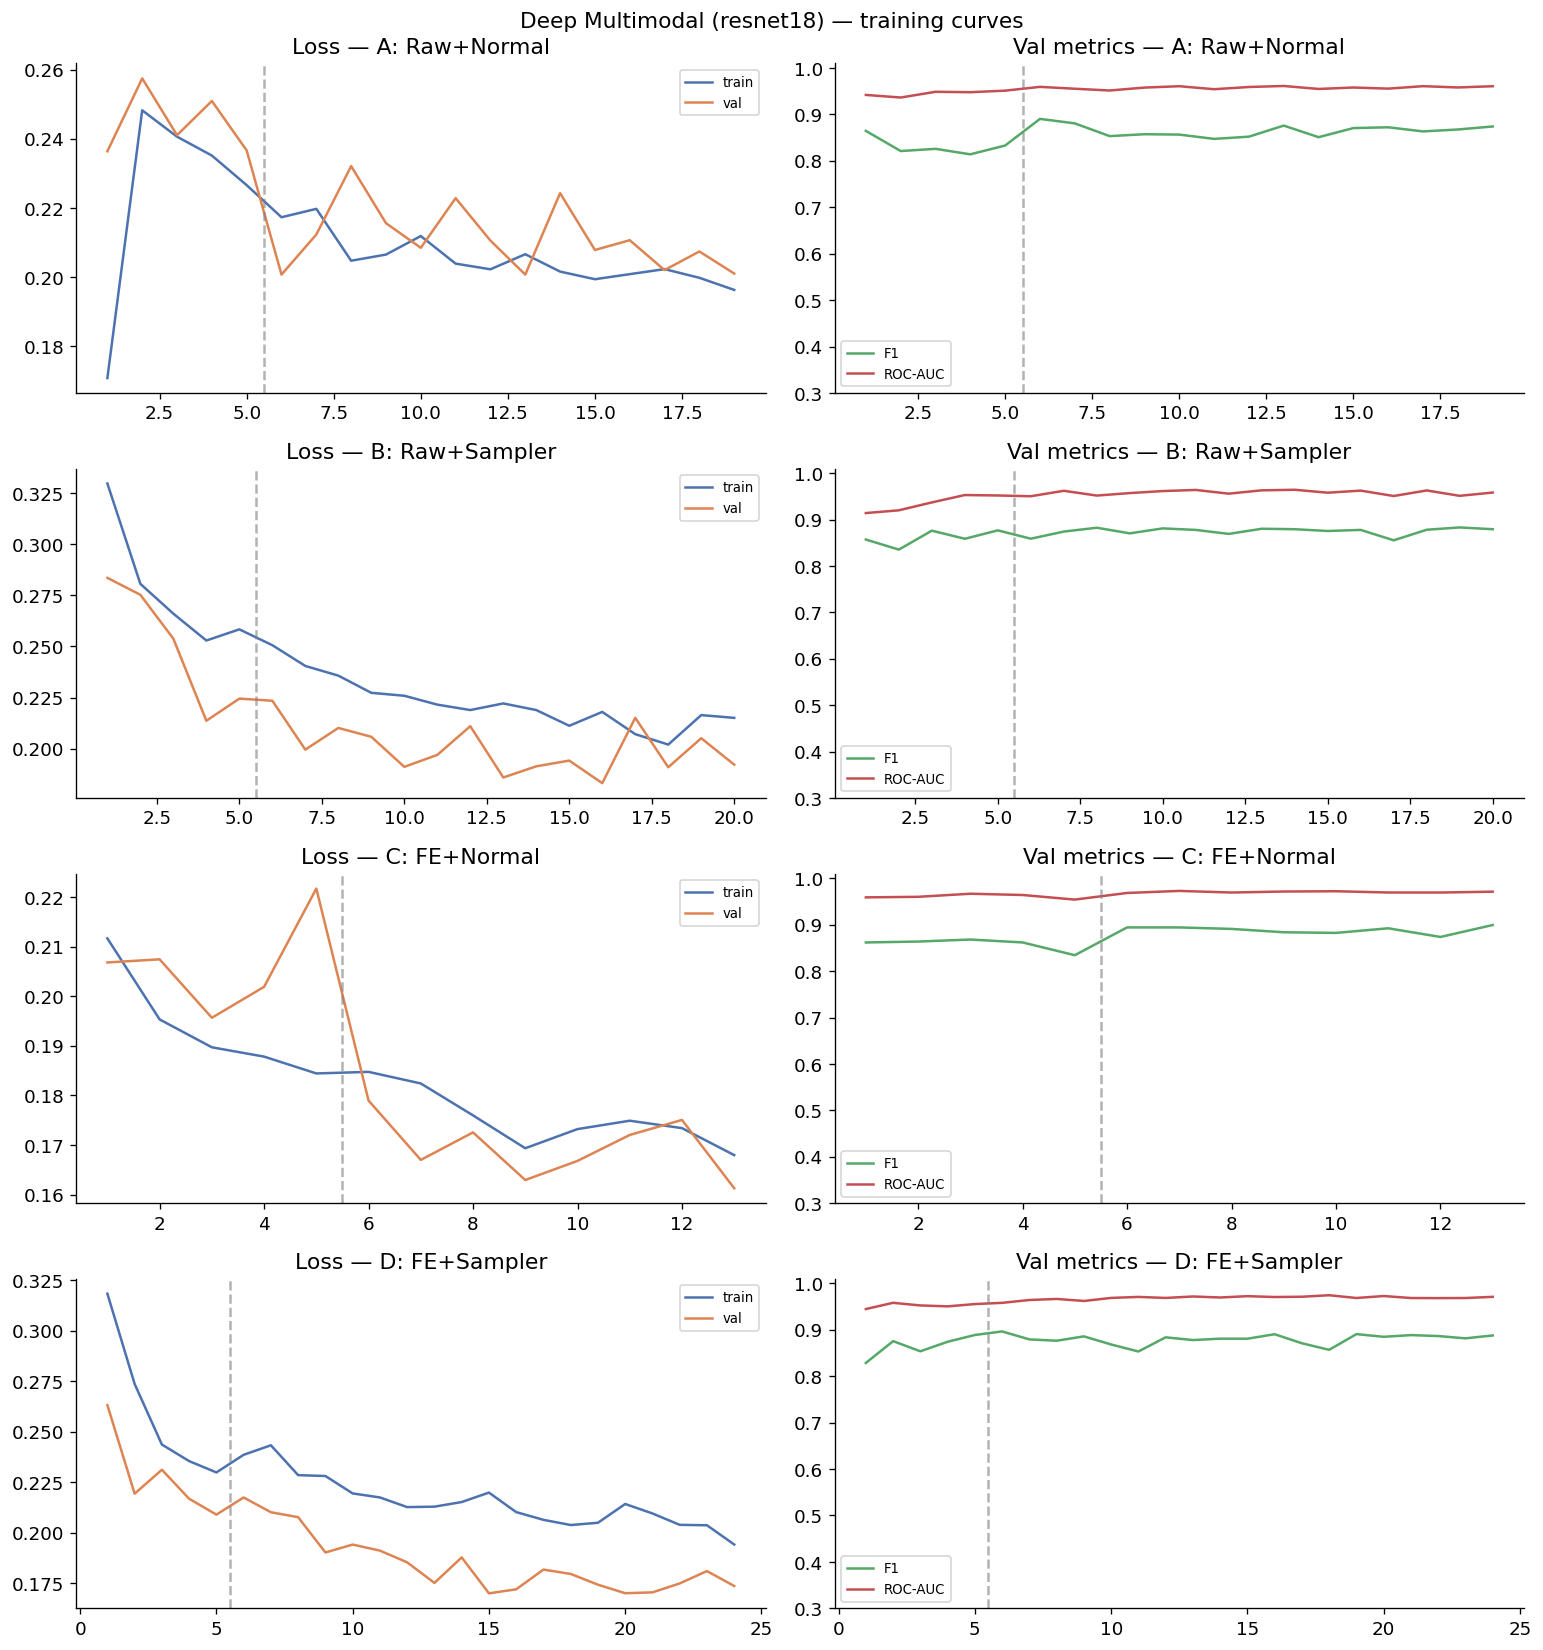

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
for row, (exp_id, label) in enumerate(zip(EXP_DIRS.keys(), labels)):
    hist_path = EXP_DIRS[exp_id] / "training_history.csv"
    if not hist_path.exists():
        print(f"No history for {exp_id}"); continue
    hist = pd.read_csv(hist_path)
    if "epoch_global" not in hist.columns:
        hist["epoch_global"] = range(1, len(hist)+1)
    ep = hist["epoch_global"]

    axes[row,0].plot(ep, hist["train_loss"], label="train", color="#4C72B0")
    axes[row,0].plot(ep, hist["val_loss"],   label="val",   color="#DD8452")
    axes[row,0].set_title(f"Loss — {label}"); axes[row,0].legend(fontsize=8)
    axes[row,0].axvline(x=STAGE1_EPOCHS+0.5, color="gray", linestyle="--", alpha=0.6)

    axes[row,1].plot(ep, hist["val_f1"],      label="F1",      color="#55A868")
    axes[row,1].plot(ep, hist["val_roc_auc"], label="ROC-AUC", color="#C44E52")
    axes[row,1].set_ylim(0.3,1.01)
    axes[row,1].set_title(f"Val metrics — {label}"); axes[row,1].legend(fontsize=8)
    axes[row,1].axvline(x=STAGE1_EPOCHS+0.5, color="gray", linestyle="--", alpha=0.6)

    for ax in axes[row]:
        ax.spines[["top","right"]].set_visible(False)

fig.suptitle(f"Deep Multimodal ({BACKBONE}) — training curves", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_BASE/"training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Overall metrics comparison
Axis 1: Normal vs Sampler | Axis 2: Raw vs FE

,experiment,features,sampler,threshold,accuracy,precision,recall,f1,roc_auc
0,A_raw_normal,Raw,Normal,0.25,0.8982,0.8945,0.9489,0.9209,0.9671
1,B_raw_sampler,Raw,Sampler,0.30,0.8894,0.8874,0.9424,0.9141,0.9642
2,C_fe_normal,Engineered,Normal,0.35,0.9186,0.9228,0.9489,0.9357,0.9792
3,D_fe_sampler,Engineered,Sampler,0.20,0.9186,0.9124,0.9620,0.9365,0.9795


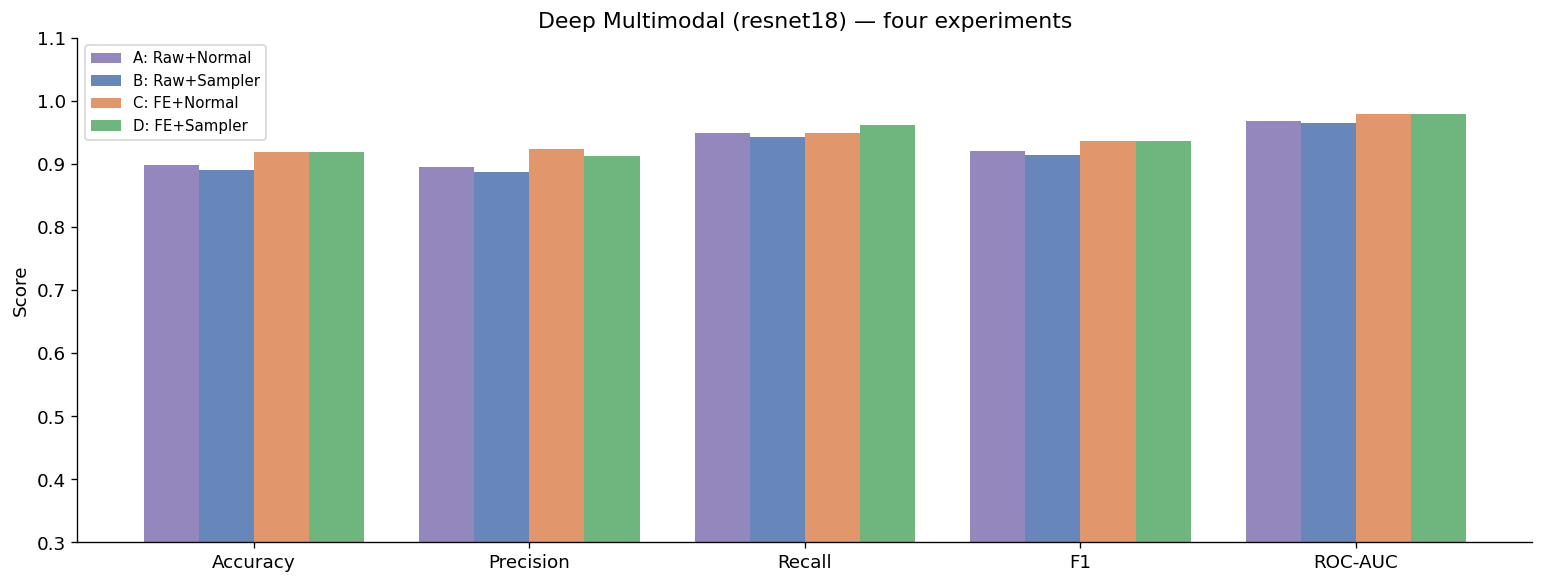

In [23]:
cmp = pd.DataFrame([
    {"experiment": r["id"],
     "features": "Raw" if "raw" in r["id"] else "Engineered",
     "sampler":   "Sampler" if "sampler" in r["id"] else "Normal",
     "threshold": r["threshold"],
     "accuracy":  r["metrics"]["accuracy"],
     "precision": r["metrics"]["precision"],
     "recall":    r["metrics"]["recall"],
     "f1":        r["metrics"]["f1"],
     "roc_auc":   r["metrics"]["roc_auc"]}
    for r in results
])
display(cmp.round(4))
cmp.to_csv(RESULTS_BASE/"comparison.csv", index=False)

# Grouped bar chart
metrics_plot = ["accuracy","precision","recall","f1","roc_auc"]
x = np.arange(len(metrics_plot)); width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
for i, (r, label, colour) in enumerate(zip(results, labels, colours)):
    ax.bar(x + i*width, [r["metrics"][m] for m in metrics_plot],
           width, label=label, color=colour, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(["Accuracy","Precision","Recall","F1","ROC-AUC"])
ax.set_ylim(0.3, 1.1); ax.set_ylabel("Score")
ax.set_title(f"Deep Multimodal ({BACKBONE}) — four experiments")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_BASE/"comparison_overall.png", dpi=150, bbox_inches="tight")
plt.show()

## 12 · PR and ROC curves

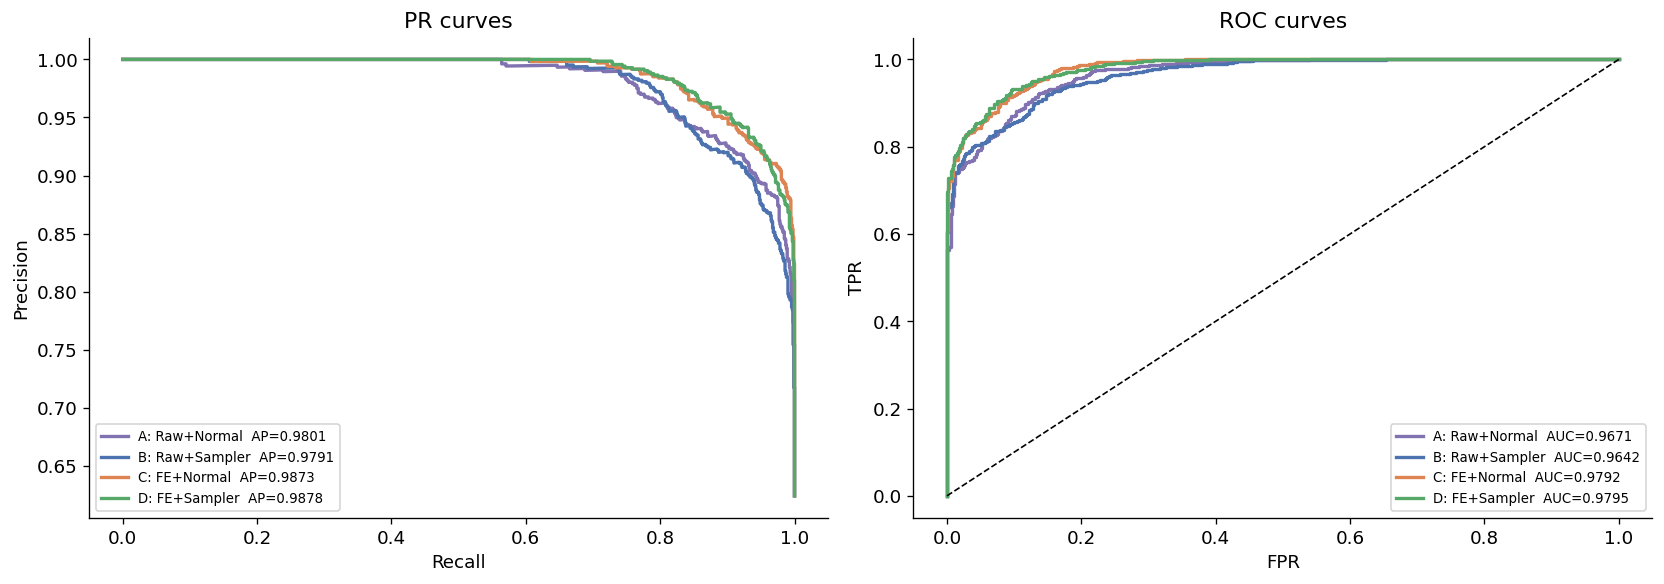

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r, label, colour in zip(results, labels, colours):
    # PR
    prec, rec, _ = precision_recall_curve(r["y_true"], r["y_prob"])
    ap = average_precision_score(r["y_true"], r["y_prob"])
    axes[0].plot(rec, prec, color=colour, lw=2, label=f"{label}  AP={ap:.4f}")
    # ROC
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    axes[1].plot(fpr, tpr, color=colour, lw=2,
                 label=f"{label}  AUC={sk_auc(fpr,tpr):.4f}")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("PR curves"); axes[0].legend(fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)
axes[1].plot([0,1],[0,1],"k--",lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC curves"); axes[1].legend(fontsize=8)
axes[1].spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_BASE/"pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 13 · Subgroup analysis by combo_type
**The key diagnostic.** Image-only models showed tab0_img0 F1=0.000 and
tab1_img0 F1≈0.35. The multimodal model should improve both because it
sees transaction features alongside the image.

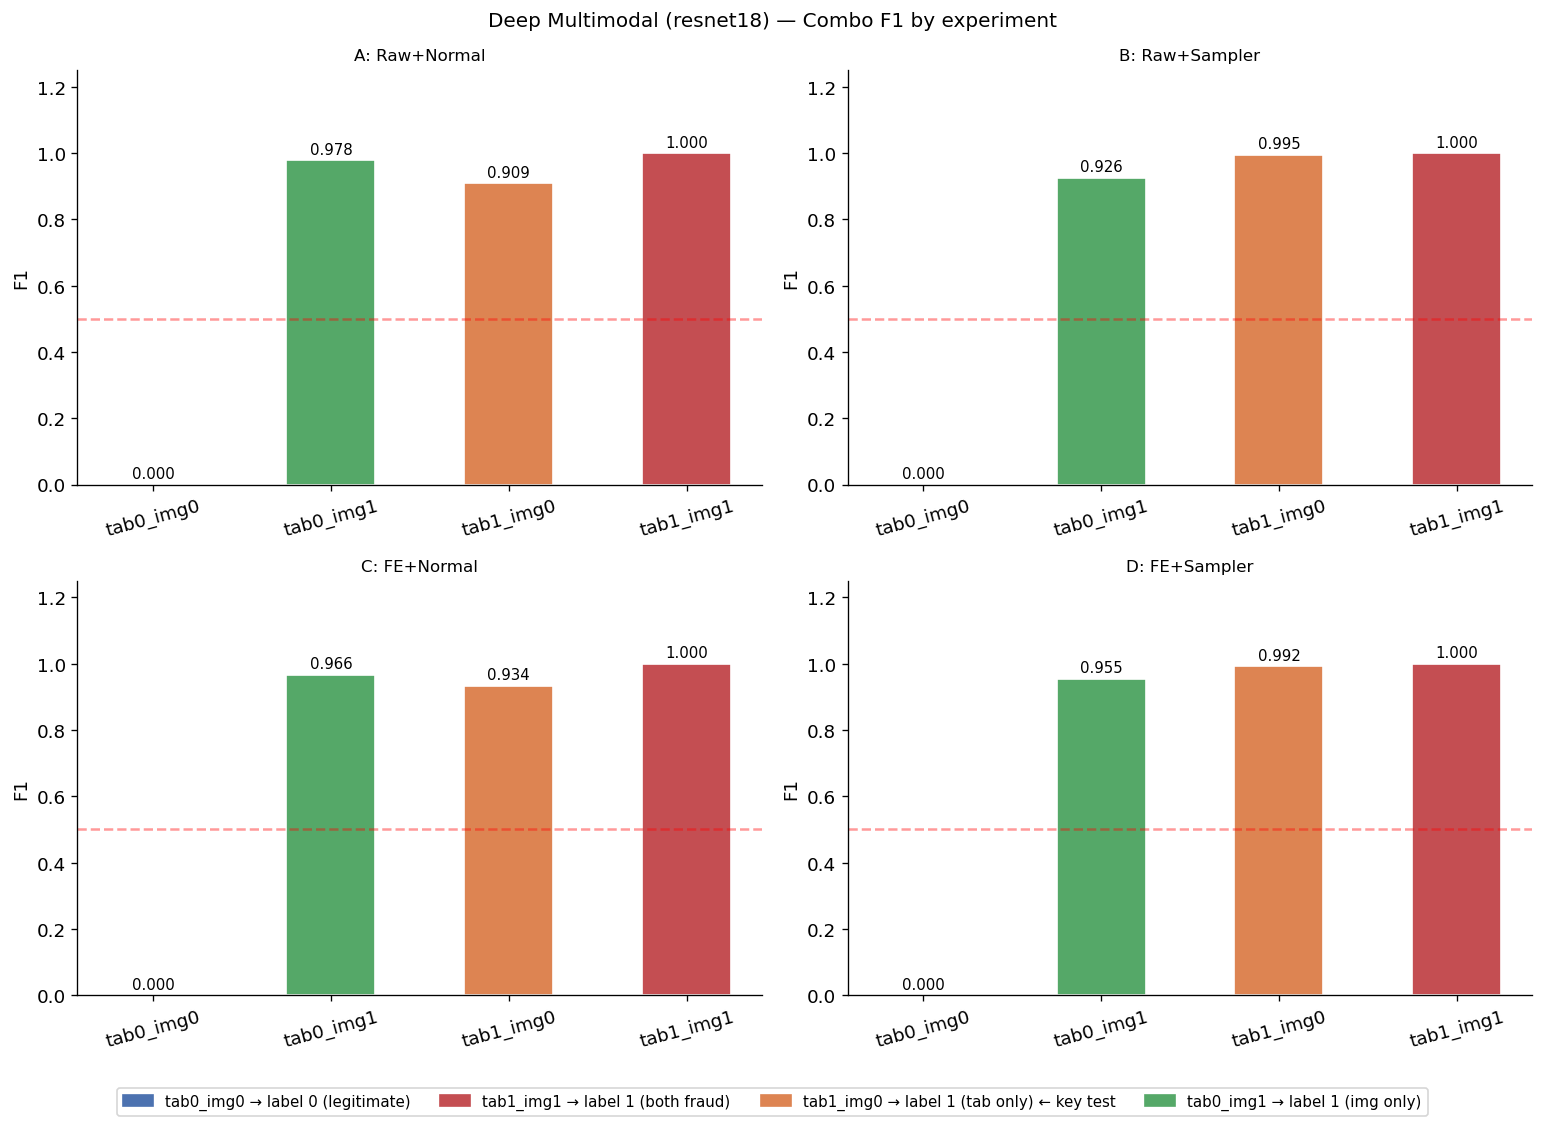


Subgroup F1 comparison:


,A_raw_normal,B_raw_sampler,C_fe_normal,D_fe_sampler
combo_type,,,,
tab0_img0,0.000,0.000,0.000,0.000
tab0_img1,0.978,0.926,0.966,0.955
tab1_img0,0.909,0.995,0.934,0.992
tab1_img1,1.000,1.000,1.000,1.000


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, r, label in zip(axes.flat, results, labels):
    sg = r["sg"]
    clrs = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"], color=clrs, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.25); ax.set_title(label, fontsize=10)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="random")
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

fig.legend(handles=[
    Patch(color="#4C72B0",label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52",label="tab1_img1 → label 1 (both fraud)"),
    Patch(color="#DD8452",label="tab1_img0 → label 1 (tab only) ← key test"),
    Patch(color="#55A868",label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.05), fontsize=9)
fig.suptitle(f"Deep Multimodal ({BACKBONE}) — Combo F1 by experiment", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE/"subgroup_combo.png", dpi=150, bbox_inches="tight")
plt.show()

# Comparison table
print("\nSubgroup F1 comparison:")
sg_cmp = pd.concat([
    r["sg"].set_index("combo_type")[["f1"]].rename(columns={"f1":r["id"]})
    for r in results
], axis=1).round(3)
display(sg_cmp)
sg_cmp.to_csv(RESULTS_BASE/"subgroup_comparison.csv")

## 14 · Score distributions

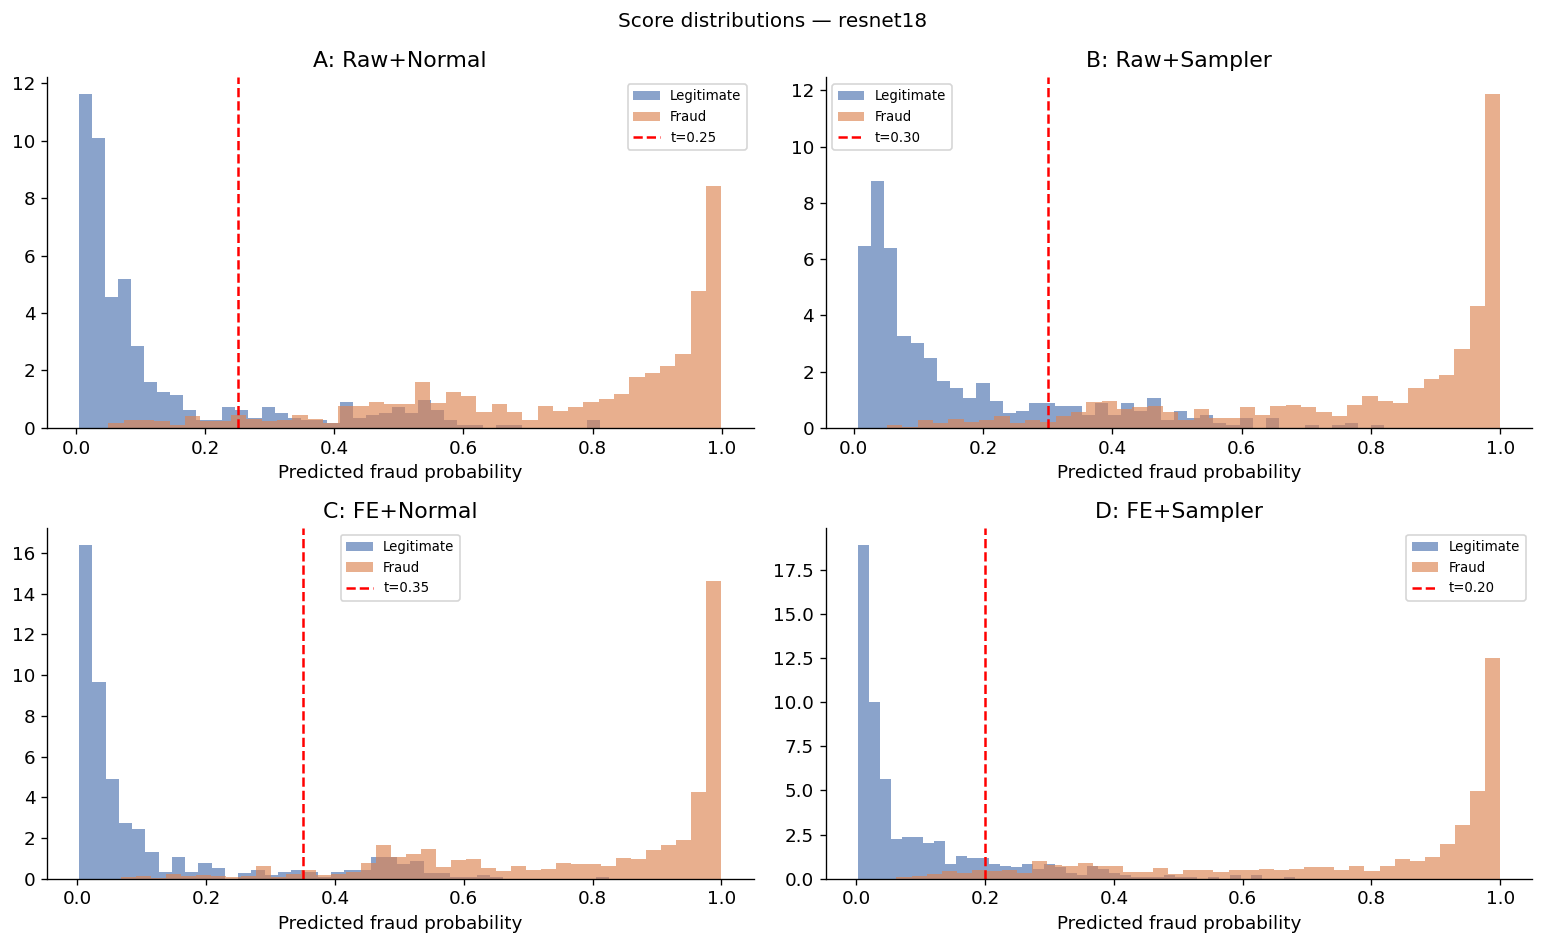

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, r, label in zip(axes.flat, results, labels):
    ax.hist(r["y_prob"][r["y_true"]==0], bins=40, alpha=0.65,
            color="#4C72B0", label="Legitimate", density=True)
    ax.hist(r["y_prob"][r["y_true"]==1], bins=40, alpha=0.65,
            color="#DD8452", label="Fraud", density=True)
    ax.axvline(x=r["threshold"], color="red", linestyle="--",
               label=f"t={r['threshold']:.2f}")
    ax.set_title(label); ax.set_xlabel("Predicted fraud probability")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
fig.suptitle(f"Score distributions — {BACKBONE}", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE/"score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 15 · Final summary table

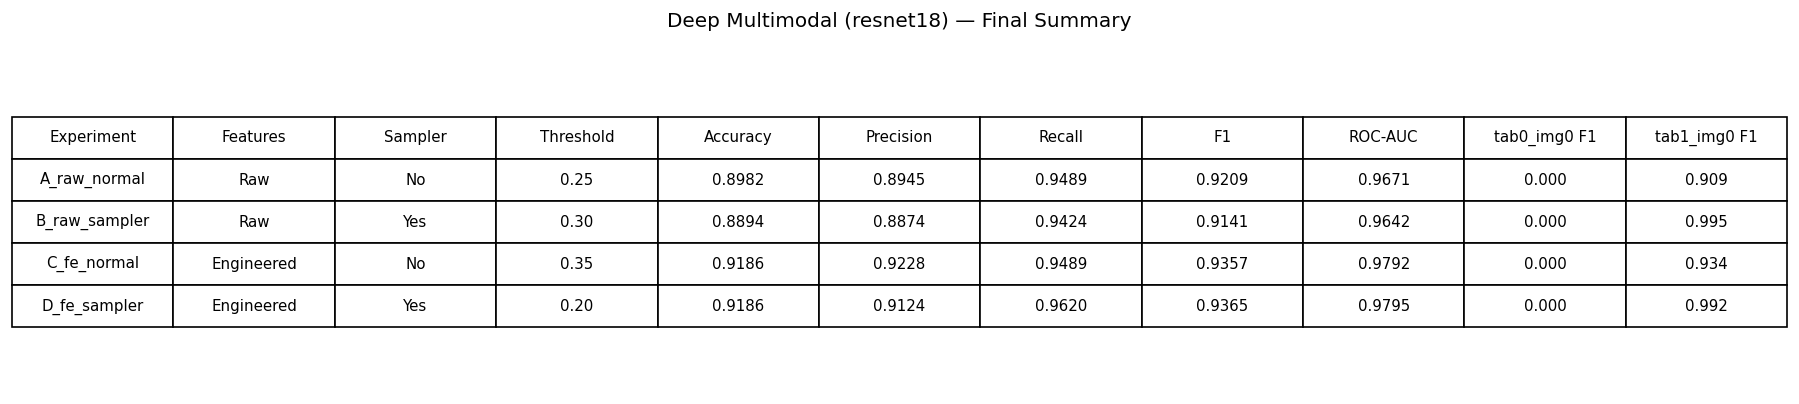

Best experiment: D_fe_sampler
  F1      : 0.9365
  ROC-AUC : 0.9795
  tab0_img0 F1: 0.000
  tab1_img0 F1: 0.992

All results saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18


In [27]:
def gf1(sg, combo):
    r = sg[sg["combo_type"]==combo]
    return f"{r['f1'].values[0]:.3f}" if len(r)>0 else "N/A"

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.axis("off")
col_labels = ["Experiment","Features","Sampler","Threshold",
              "Accuracy","Precision","Recall","F1","ROC-AUC",
              "tab0_img0 F1","tab1_img0 F1"]
cell_data = [
    [r["id"],
     "Raw" if "raw" in r["id"] else "Engineered",
     "Yes" if "sampler" in r["id"] else "No",
     f"{r['threshold']:.2f}",
     f"{r['metrics']['accuracy']:.4f}",
     f"{r['metrics']['precision']:.4f}",
     f"{r['metrics']['recall']:.4f}",
     f"{r['metrics']['f1']:.4f}",
     f"{r['metrics']['roc_auc']:.4f}",
     gf1(r["sg"],"tab0_img0"),
     gf1(r["sg"],"tab1_img0")]
    for r in results
]
tbl = ax.table(cellText=cell_data, colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.05, 2.0)
ax.set_title(f"Deep Multimodal ({BACKBONE}) — Final Summary", fontsize=12, pad=15)
fig.tight_layout()
fig.savefig(RESULTS_BASE/"final_summary.png", dpi=150, bbox_inches="tight")
plt.show()

best = max(results, key=lambda r: r["metrics"]["f1"])
print(f"Best experiment: {best['id']}")
print(f"  F1      : {best['metrics']['f1']:.4f}")
print(f"  ROC-AUC : {best['metrics']['roc_auc']:.4f}")
print(f"  tab0_img0 F1: {gf1(best['sg'],'tab0_img0')}")
print(f"  tab1_img0 F1: {gf1(best['sg'],'tab1_img0')}")
print(f"\nAll results saved to: {RESULTS_BASE}")

In [28]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

for combo in ["tab0_img0", "tab0_img1", "tab1_img0", "tab1_img1"]:
    g = res_A["pred_df"][res_A["pred_df"]["combo_type"] == combo]

    y_true = g["y_true"]
    y_pred = g["y_pred"]

    print("\n", combo)
    print("n:", len(g))
    print("true label counts:")
    print(y_true.value_counts())
    print("pred label counts:")
    print(y_pred.value_counts())
    print("accuracy:", accuracy_score(y_true, y_pred))
    print("F1 fraud label 1:", f1_score(y_true, y_pred, pos_label=1, zero_division=0))
    print("F1 legitimate label 0:", f1_score(y_true, y_pred, pos_label=0, zero_division=0))


 tab0_img0
n: 554
true label counts:
y_true
0    554
Name: count, dtype: int64
pred label counts:
y_pred
0    451
1    103
Name: count, dtype: int64
accuracy: 0.8140794223826715
F1 fraud label 1: 0.0
F1 legitimate label 0: 0.8975124378109453

 tab0_img1
n: 368
true label counts:
y_true
1    368
Name: count, dtype: int64
pred label counts:
y_pred
1    352
0     16
Name: count, dtype: int64
accuracy: 0.9565217391304348
F1 fraud label 1: 0.9777777777777777
F1 legitimate label 0: 0.0

 tab1_img0
n: 185
true label counts:
y_true
1    185
Name: count, dtype: int64
pred label counts:
y_pred
1    154
0     31
Name: count, dtype: int64
accuracy: 0.8324324324324325
F1 fraud label 1: 0.9085545722713865
F1 legitimate label 0: 0.0

 tab1_img1
n: 367
true label counts:
y_true
1    367
Name: count, dtype: int64
pred label counts:
y_pred
1    367
Name: count, dtype: int64
accuracy: 1.0
F1 fraud label 1: 1.0
F1 legitimate label 0: 0.0


In [29]:
from sklearn.metrics import f1_score, accuracy_score

def combo_metrics_fixed(res):
    df = res["pred_df"].copy()

    rows = {}

    for combo, g in df.groupby("combo_type"):
        y_true = g["y_true"]
        y_pred = g["y_pred"]

        acc = accuracy_score(y_true, y_pred)

        if combo == "tab0_img0":
            # legitimate-only group, so use label 0
            legit_f1 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
            false_positives = ((y_true == 0) & (y_pred == 1)).sum()
            true_legit = (y_true == 0).sum()
            fpr = false_positives / true_legit if true_legit > 0 else float("nan")

            rows["tab0_img0_acc"] = acc
            rows["tab0_img0_legit_f1"] = legit_f1
            rows["tab0_img0_fpr"] = fpr

        elif combo == "tab1_img0":
            # tabular-only fraud group, use label 1
            fraud_f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
            rows["tab1_img0_f1"] = fraud_f1
            rows["tab1_img0_acc"] = acc

        else:
            rows[f"{combo}_acc"] = acc

    return rows

In [32]:
summary_rows = []

for res, features, sampler in [
    (res_A, "Raw", "No"),
    (res_B, "Raw", "Yes"),
    (res_C, "Engineered", "No"),
    (res_D, "Engineered", "Yes"),
]:
    m = res["metrics"]
    combo = combo_metrics_fixed(res)

    summary_rows.append({
        "Experiment": res["id"],
        "Features": features,
        "Sampler": sampler,
        "Threshold": res["threshold"],

        "Accuracy": m.get("accuracy"),
        "Precision": m.get("precision"),
        "Recall": m.get("recall"),
        "F1": m.get("f1"),
        "ROC-AUC": m.get("roc_auc"),

        # fixed columns
        "tab0_img0 Legit F1": combo.get("tab0_img0_legit_f1"),
        "tab0_img0 FPR": combo.get("tab0_img0_fpr"),
        "tab1_img0 Fraud F1": combo.get("tab1_img0_f1"),
    })

summary_df_fixed = pd.DataFrame(summary_rows)

summary_df_fixed

,Experiment,Features,Sampler,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,tab0_img0 Legit F1,tab0_img0 FPR,tab1_img0 Fraud F1
0,A_raw_normal,Raw,No,0.25,0.898236,0.894467,0.948913,0.920886,0.967052,0.897512,0.185921,0.908555
1,B_raw_sampler,Raw,Yes,0.30,0.889417,0.887410,0.942391,0.914075,0.964178,0.889780,0.198556,0.994565
2,C_fe_normal,Engineered,No,0.35,0.918589,0.922833,0.948913,0.935691,0.979169,0.929469,0.131769,0.933718
3,D_fe_sampler,Engineered,Yes,0.20,0.918589,0.912371,0.961957,0.936508,0.979528,0.916911,0.153430,0.991826


In [34]:
summary_df_fixed_round = summary_df_fixed.copy()

num_cols = [
    "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC",
    "tab0_img0 Legit F1", "tab0_img0 FPR", "tab1_img0 Fraud F1"
]

summary_df_fixed_round[num_cols] = summary_df_fixed_round[num_cols].round(4)

print(summary_df_fixed_round)

      Experiment    Features Sampler  Threshold  Accuracy  Precision  Recall  \
0   A_raw_normal         Raw      No       0.25    0.8982     0.8945  0.9489   
1  B_raw_sampler         Raw     Yes       0.30    0.8894     0.8874  0.9424   
2    C_fe_normal  Engineered      No       0.35    0.9186     0.9228  0.9489   
3   D_fe_sampler  Engineered     Yes       0.20    0.9186     0.9124  0.9620   

       F1  ROC-AUC  tab0_img0 Legit F1  tab0_img0 FPR  tab1_img0 Fraud F1  
0  0.9209   0.9671              0.8975         0.1859              0.9086  
1  0.9141   0.9642              0.8898         0.1986              0.9946  
2  0.9357   0.9792              0.9295         0.1318              0.9337  
3  0.9365   0.9795              0.9169         0.1534              0.9918  
